# Part 4 — Vector Databases: Embeddings & Semantic Similarity

**Topics:** Cricket | Cooking | Cybersecurity  
**Model:** `all-MiniLM-L6-v2` via `sentence-transformers`  
**Tasks:**
1. Generate embeddings for 10 sentences across 3 topics
2. Display a 10×10 cosine similarity matrix as a heatmap
3. Find top 2 most similar sentences to a new cricket query

In [1]:
# Install required libraries
!pip install sentence-transformers seaborn scikit-learn -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Step 1 — Define 10 Sentences Across 3 Topics

In [3]:
# 10 sentences: 4 Cricket, 3 Cooking, 3 Cybersecurity
sentences = [
    # Cricket (0–3)
    'The batsman hit a magnificent century in the final over.',
    'India won the Test match by a margin of seven wickets.',
    'The spinner delivered a sharp googly that confused the batsman.',
    'A perfect yorker at the death overs sealed the victory for the team.',

    # Cooking (4–6)
    'Saute the onions in olive oil until they turn golden brown.',
    'Marinate the chicken in yogurt and spices for at least two hours.',
    'Fold the egg whites gently into the batter to keep it light and fluffy.',

    # Cybersecurity (7–9)
    'The hacker exploited a SQL injection vulnerability to access the database.',
    'Always enable two-factor authentication to protect your online accounts.',
    'Ransomware encrypted all company files and demanded a Bitcoin payment.',
]

labels = [
    'Cricket-1', 'Cricket-2', 'Cricket-3', 'Cricket-4',
    'Cooking-1', 'Cooking-2', 'Cooking-3',
    'Cyber-1',   'Cyber-2',   'Cyber-3',
]

print(f'Total sentences: {len(sentences)}')
for i, s in enumerate(sentences):
    print(f'  [{labels[i]:10s}] {s}')

Total sentences: 10
  [Cricket-1 ] The batsman hit a magnificent century in the final over.
  [Cricket-2 ] India won the Test match by a margin of seven wickets.
  [Cricket-3 ] The spinner delivered a sharp googly that confused the batsman.
  [Cricket-4 ] A perfect yorker at the death overs sealed the victory for the team.
  [Cooking-1 ] Saute the onions in olive oil until they turn golden brown.
  [Cooking-2 ] Marinate the chicken in yogurt and spices for at least two hours.
  [Cooking-3 ] Fold the egg whites gently into the batter to keep it light and fluffy.
  [Cyber-1   ] The hacker exploited a SQL injection vulnerability to access the database.
  [Cyber-2   ] Always enable two-factor authentication to protect your online accounts.
  [Cyber-3   ] Ransomware encrypted all company files and demanded a Bitcoin payment.


## Step 2 — Load Model and Generate Embeddings

In [4]:
# Load the sentence-transformers model
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded: all-MiniLM-L6-v2')

# Generate embeddings — each sentence → 384-dimensional vector
embeddings = model.encode(sentences, show_progress_bar=True)

print(f'\nEmbedding matrix shape: {embeddings.shape}')
print(f'Each sentence is a {embeddings.shape[1]}-dimensional vector.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding matrix shape: (10, 384)
Each sentence is a 384-dimensional vector.


## Step 3 — Compute 10×10 Cosine Similarity Matrix

In [5]:
# Compute pairwise cosine similarity
similarity_matrix = cosine_similarity(embeddings)

print('Cosine Similarity Matrix (10x10):')
print(np.round(similarity_matrix, 3))

Cosine Similarity Matrix (10x10):
[[ 1.     0.575  0.527  0.439  0.038  0.043  0.113  0.058 -0.016  0.027]
 [ 0.575  1.     0.435  0.38   0.032 -0.001  0.07   0.112 -0.067  0.115]
 [ 0.527  0.435  1.     0.358  0.061  0.056  0.19   0.193 -0.069  0.016]
 [ 0.439  0.38   0.358  1.     0.095  0.042  0.093  0.059 -0.01   0.112]
 [ 0.038  0.032  0.061  0.095  1.     0.288  0.385 -0.    -0.016  0.011]
 [ 0.043 -0.001  0.056  0.042  0.288  1.     0.246  0.057 -0.036 -0.006]
 [ 0.113  0.07   0.19   0.093  0.385  0.246  1.     0.012  0.034 -0.022]
 [ 0.058  0.112  0.193  0.059 -0.     0.057  0.012  1.     0.143  0.305]
 [-0.016 -0.067 -0.069 -0.01  -0.016 -0.036  0.034  0.143  1.     0.078]
 [ 0.027  0.115  0.016  0.112  0.011 -0.006 -0.022  0.305  0.078  1.   ]]


## Step 4 — Visualize as Heatmap

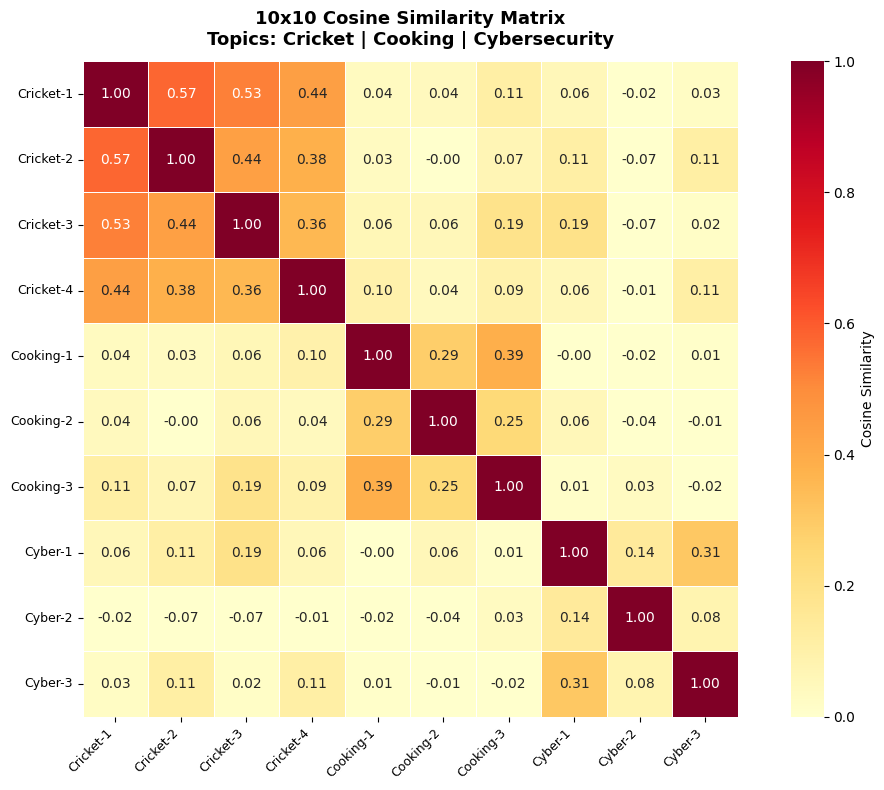

Heatmap saved as similarity_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    similarity_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'label': 'Cosine Similarity'}
)

ax.set_title(
    '10x10 Cosine Similarity Matrix\nTopics: Cricket | Cooking | Cybersecurity',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as similarity_heatmap.png')

## Step 5 — Find Top 2 Most Similar Sentences to Query

In [7]:
# Query sentence as specified in the assignment
query = 'The bowler took three wickets in one over.'

# Embed the query
query_embedding = model.encode([query])

# Compute cosine similarity between query and all 10 sentences
scores = cosine_similarity(query_embedding, embeddings)[0]

print(f'Query: "{query}"')
print(f'\nSimilarity scores:')
for i, (s, sc) in enumerate(zip(sentences, scores)):
    print(f'  {labels[i]:10s}  {sc:.4f}  {s}')

# Get top 2
top2 = np.argsort(scores)[::-1][:2]
print(f'\n{"="*55}')
print('TOP 2 MOST SIMILAR SENTENCES:')
print('='*55)
for rank, idx in enumerate(top2, 1):
    print(f'\nRank {rank}: [{labels[idx]}]')
    print(f'  Sentence  : {sentences[idx]}')
    print(f'  Similarity: {scores[idx]:.4f}')

Query: "The bowler took three wickets in one over."

Similarity scores:
  Cricket-1   0.6175  The batsman hit a magnificent century in the final over.
  Cricket-2   0.6711  India won the Test match by a margin of seven wickets.
  Cricket-3   0.5319  The spinner delivered a sharp googly that confused the batsman.
  Cricket-4   0.3739  A perfect yorker at the death overs sealed the victory for the team.
  Cooking-1   0.0880  Saute the onions in olive oil until they turn golden brown.
  Cooking-2   0.0449  Marinate the chicken in yogurt and spices for at least two hours.
  Cooking-3   0.0973  Fold the egg whites gently into the batter to keep it light and fluffy.
  Cyber-1     0.1358  The hacker exploited a SQL injection vulnerability to access the database.
  Cyber-2     -0.0405  Always enable two-factor authentication to protect your online accounts.
  Cyber-3     0.1060  Ransomware encrypted all company files and demanded a Bitcoin payment.

TOP 2 MOST SIMILAR SENTENCES:

Rank 1: [Cric

## Summary

- **Model:** `all-MiniLM-L6-v2` produces 384-dimensional embeddings optimised for semantic similarity.
- **Observation:** The heatmap shows high similarity (warm colours) within each topic block and low similarity across topics — confirming semantic grouping.
- **Query result:** The cricket query correctly retrieves the top 2 most similar cricket sentences by meaning, not just keyword overlap.